# RAGFlow PDF 前端跳转指南 — OCR 场景版

## 场景说明

本指南针对**图片型 PDF（扫描件）**经 **OCR 解析** 后，前端如何根据 chunk 数据跳转到 PDF 对应页码的完整流程。

## 核心思想

```
PDF 扫描件（每页一张图片）
       │
       ▼
OCR 引擎逐页识别 → 输出文本 + 页码(page_number)
       │
       ▼
文本分块(chunk) → 自带 page_number 字段
       │
       ▼
前端读取 chunk.positions[0].page_number
       │
       ▼
PDF 查看器跳转到该页
```

> **关键认知**：chunk 的 `page_number` 不是前端算出来的，而是 OCR 解析阶段就存好的。
> PDF 第 N 页的图片 → OCR 识别 → 第 N 页的文本 → chunk 记下 `page_number = N`。


## 完整数据流

```
文档入库阶段（后端，只做一次）              查询阶段（每次用户提问）
────────────────────────                  ────────────────────
图片型 PDF（扫描件）                        用户提问
   │                                            │
   ▼                                            ▼
逐页转图片 (pdf2image)                      RAG 检索
   │                                            │
   ▼                                            ▼
每张图片 OCR 识别 → 文本+坐标+页码         命中 chunk（含 page_number）
   │                                            │
   ▼                                            ▼
文本分块(chunking) → chunk 继承页码        前端 chunk.positions[0].page_number
   │                                            │
   ▼                                            ▼
存入数据库                                    react-pdf 跳转到该页
```



## 环境准备

安装依赖：reportlab（生成 mock PDF）、pdf2image（PDF 转图片）、Pillow（图片处理）。


In [3]:
%pip install reportlab pdf2image Pillow -q 2>&1 | tail -3
# 注意: 用 %pip 而不是 !pip，确保包安装到当前内核
# 如果还是报错 ModuleNotFoundError，运行后重启内核即可

Note: you may need to restart the kernel to use updated packages.


'tail' �����ڲ����ⲿ���Ҳ���ǿ����еĳ���
���������ļ���


In [1]:
import json, os, sys
from io import BytesIO
from dataclasses import dataclass, field
from typing import List, Optional

# 如果上一行 %pip install 后仍报错，请点击菜单 Kernel → Restart Kernel 后再运行本 cell
try:
    from PIL import Image
except ModuleNotFoundError:
    %pip install Pillow -q
    from PIL import Image

print(f"Python {sys.version}")
print("Dependencies ready")


Python 3.14.3 (tags/v3.14.3:323c59a, Feb  3 2026, 16:04:56) [MSC v.1944 64 bit (AMD64)]
Dependencies ready


## Step 1: 生成 mock 扫描件 PDF

模拟一个 3 页的图片型 PDF（扫描件），每页有不同的内容。


In [2]:
from reportlab.lib.pagesizes import A4
from reportlab.pdfgen import canvas
from reportlab.lib.units import mm

def create_mock_scanned_pdf(output_path):
    """生成一个模拟扫描件的 3 页 PDF"""
    c = canvas.Canvas(output_path, pagesize=A4)
    w, h = A4
    m = 50

    # ===== 第 1 页：封面 =====
    c.setFont("Helvetica-Bold", 28)
    c.drawString(m, h - 100, "Annual Report 2025")
    c.setFont("Helvetica", 16)
    c.drawString(m, h - 140, "RAGFlow Corporation")
    c.setFont("Helvetica", 12)
    c.drawString(m, h - 170, "Published: January 2025")
    c.drawString(m, h - 200, "Confidential")
    # 模拟扫描件的"图片感"：画一个灰色背景框
    c.setFillColorRGB(0.95, 0.95, 0.95)
    c.rect(m, h - 350, w - 2*m, 120, fill=1, stroke=0)
    c.setFillColorRGB(0, 0, 0)
    c.setFont("Helvetica", 10)
    c.drawString(m + 10, h - 280, "[SCANNED DOCUMENT - Image Page 1]")
    c.showPage()

    # ===== 第 2 页：目录 =====
    c.setFont("Helvetica-Bold", 18)
    c.drawString(m, h - 60, "Table of Contents")
    c.setFont("Helvetica", 13)
    items = [
        "1. Executive Summary ................... 3",
        "2. Financial Highlights ................ 5",
        "3. Product Development ................. 7",
        "4. Market Analysis .................... 9",
        "5. Future Outlook .................... 11",
    ]
    y = h - 110
    for item in items:
        c.drawString(m + 20, y, item)
        y -= 25
    c.setFillColorRGB(0.95, 0.95, 0.95)
    c.rect(m, h - 300, w - 2*m, 80, fill=1, stroke=0)
    c.setFillColorRGB(0, 0, 0)
    c.setFont("Helvetica", 10)
    c.drawString(m + 10, h - 260, "[SCANNED DOCUMENT - Image Page 2]")
    c.showPage()

    # ===== 第 3 页：正文 =====
    c.setFont("Helvetica-Bold", 18)
    c.drawString(m, h - 60, "1. Executive Summary")
    c.setFont("Helvetica", 12)
    body_text = [
        "Retrieval-Augmented Generation (RAG) is a powerful paradigm that",
        "combines information retrieval with large language models. In 2025,",
        "RAGFlow achieved significant milestones in document understanding.",
        "",
        "Our OCR pipeline processed over 10 million scanned documents,",
        "extracting text with 99.2% accuracy across 50+ languages.",
        "The system supports both text-based PDFs and scanned images.",
        "",
        "Key achievements this year:",
        "  - Launched real-time document parsing",
        "  - Improved chunking algorithm for better retrieval",
        "  - Reduced latency by 40% in the OCR pipeline",
        "  - Added support for handwritten text recognition",
    ]
    y = h - 100
    for line in body_text:
        c.drawString(m, y, line)
        y -= 20

    c.setFillColorRGB(0.95, 0.95, 0.95)
    c.rect(m, h - 450, w - 2*m, 80, fill=1, stroke=0)
    c.setFillColorRGB(0, 0, 0)
    c.setFont("Helvetica", 10)
    c.drawString(m + 10, h - 410, "[SCANNED DOCUMENT - Image Page 3]")
    c.save()
    return output_path

os.makedirs("mock_output", exist_ok=True)
pdf_path = create_mock_scanned_pdf("mock_output/scanned_report.pdf")
print(f"PDF created: {pdf_path}")
print(f"File size: {os.path.getsize(pdf_path)} bytes")
print("Pages: 3 (Cover, TOC, Content)")


PDF created: mock_output/scanned_report.pdf
File size: 3549 bytes
Pages: 3 (Cover, TOC, Content)


## Step 2: 模拟 OCR 解析 — 逐页提取文本

模拟真实 OCR 流程：将 PDF 每页转图片 → 对每张图片"识别"文本 → 记录页码。


In [4]:
# ===== OCR 解析模拟 =====
# 真实场景会调用 PaddleOCR / Tesseract 等引擎
# 这里用 reportlab 写的内容直接作为 OCR 结果

# pdf2image 在 Windows 上需要 poppler
# 如果没有 poppler，会使用备用方案（直接用 PIL 生成空白页示意）
try:
    from pdf2image import convert_from_path
    POPPLER_AVAILABLE = True
except Exception:
    POPPLER_AVAILABLE = False

# 第 1 步：PDF 每页转成图片（模拟真实 OCR 流程）
print("=" * 60)
print("Step 2.1: Converting PDF pages to images...")
print("=" * 60)

if POPPLER_AVAILABLE:
    try:
        images = convert_from_path(pdf_path, dpi=150)
        print(f"Total pages converted: {len(images)}")
    except Exception as e:
        print(f"⚠️ pdf2image 调用失败 ({type(e).__name__})，使用备用方案")
        POPPLER_AVAILABLE = False

if not POPPLER_AVAILABLE:
    print("备用方案：直接用 reportlab 生成页面图片")
    from PIL import Image, ImageDraw, ImageFont
    images = []
    for pg in range(1, 4):
        img = Image.new("RGB", (1240, 1754), (255, 255, 255))
        draw = ImageDraw.Draw(img)
        draw.rectangle([0, 0, img.width, 40], fill=(59, 130, 246))
        draw.text((20, 8), f"PDF Page {pg} (simulated)", fill=(255, 255, 255))
        draw.text((50, 100), f"This is a simulated page {pg} from the scanned PDF", fill=(0, 0, 0))
        images.append(img)
    print(f"Generated {len(images)} page images (simulated)")
for i, img in enumerate(images):
    print(f"  Page {i+1}: {img.size[0]}x{img.size[1]} pixels")

# 保存图片用于后续展示
page_images = []
for i, img in enumerate(images):
    img_path = f"mock_output/page_{i+1}.png"
    img.save(img_path, "PNG")
    page_images.append(img_path)
    print(f"  Saved: {img_path}")

print("\n✅ PDF → Images conversion done")
print("(In production, each image would be sent to OCR engine)")


Step 2.1: Converting PDF pages to images...
⚠️ pdf2image 调用失败 (PDFInfoNotInstalledError)，使用备用方案
备用方案：直接用 reportlab 生成页面图片
Generated 3 page images (simulated)
  Page 1: 1240x1754 pixels
  Page 2: 1240x1754 pixels
  Page 3: 1240x1754 pixels
  Saved: mock_output/page_1.png
  Saved: mock_output/page_2.png
  Saved: mock_output/page_3.png

✅ PDF → Images conversion done
(In production, each image would be sent to OCR engine)


### Step 2.2: OCR 识别结果

模拟 OCR 引擎对每张图片的识别结果，每个结果**天然带有页码**（图片序号）。


In [5]:
# ===== 模拟 OCR 输出 =====
# 真实 OCR 引擎会返回: text + bbox + confidence
# 最关键的是：page_number = 图片序号

@dataclass
class OcrBlock:
    """OCR 识别出的一个文本块"""
    text: str
    page_number: int       # ← 这是页码！由图片序号决定
    bbox: tuple            # (x1, y1, x2, y2)

# 模拟 OCR 对每页的结果
ocr_results = [
    # 第 1 页 - 封面
    OcrBlock("Annual Report 2025", 1, (50, 500, 400, 540)),
    OcrBlock("RAGFlow Corporation", 1, (50, 470, 350, 490)),
    OcrBlock("Published: January 2025", 1, (50, 440, 300, 460)),
    OcrBlock("[SCANNED DOCUMENT - Image Page 1]", 1, (50, 300, 500, 315)),

    # 第 2 页 - 目录
    OcrBlock("Table of Contents", 2, (50, 550, 400, 575)),
    OcrBlock("1. Executive Summary ................... 3", 2, (70, 510, 450, 525)),
    OcrBlock("2. Financial Highlights ................ 5", 2, (70, 485, 450, 500)),
    OcrBlock("3. Product Development ................. 7", 2, (70, 460, 450, 475)),
    OcrBlock("4. Market Analysis .................... 9", 2, (70, 435, 450, 450)),
    OcrBlock("[SCANNED DOCUMENT - Image Page 2]", 2, (50, 320, 500, 335)),

    # 第 3 页 - 正文
    OcrBlock("1. Executive Summary", 3, (50, 550, 400, 575)),
    OcrBlock("RAG is a powerful paradigm that combines", 3, (50, 510, 500, 525)),
    OcrBlock("information retrieval with large language models.", 3, (50, 490, 500, 505)),
    OcrBlock("In 2025, RAGFlow achieved significant milestones.", 3, (50, 470, 500, 485)),
    OcrBlock("Our OCR pipeline processed over 10 million documents.", 3, (50, 440, 500, 455)),
    OcrBlock("The system supports both text PDFs and scanned images.", 3, (50, 420, 500, 435)),
    OcrBlock("[SCANNED DOCUMENT - Image Page 3]", 3, (50, 200, 500, 215)),
]

print("=" * 60)
print("Step 2.2: OCR Recognition Results (simulated)")
print("=" * 60)
for block in ocr_results:
    print(f"  Page {block.page_number}: \"{block.text[:50]}...\" " if len(block.text) > 50 else f"  Page {block.page_number}: \"{block.text}\"")
print(f"\nTotal OCR blocks: {len(ocr_results)}")
print("\n✅ OCR recognition done")
print("(Each block's page_number is determined by which page image it came from)")


Step 2.2: OCR Recognition Results (simulated)
  Page 1: "Annual Report 2025"
  Page 1: "RAGFlow Corporation"
  Page 1: "Published: January 2025"
  Page 1: "[SCANNED DOCUMENT - Image Page 1]"
  Page 2: "Table of Contents"
  Page 2: "1. Executive Summary ................... 3"
  Page 2: "2. Financial Highlights ................ 5"
  Page 2: "3. Product Development ................. 7"
  Page 2: "4. Market Analysis .................... 9"
  Page 2: "[SCANNED DOCUMENT - Image Page 2]"
  Page 3: "1. Executive Summary"
  Page 3: "RAG is a powerful paradigm that combines"
  Page 3: "information retrieval with large language models."
  Page 3: "In 2025, RAGFlow achieved significant milestones."
  Page 3: "Our OCR pipeline processed over 10 million documen..." 
  Page 3: "The system supports both text PDFs and scanned ima..." 
  Page 3: "[SCANNED DOCUMENT - Image Page 3]"

Total OCR blocks: 17

✅ OCR recognition done
(Each block's page_number is determined by which page image it came from)


## Step 3: 构建 Chunk（含 page_number）

将 OCR 结果分块，每个 chunk 保留其来源的页码。


In [6]:
@dataclass
class ChunkPosition:
    page_number: int
    bbox: dict

@dataclass
class RAGChunk:
    chunk_id: str
    content: str
    positions: List[ChunkPosition]   # ← 这里存页码！
    doc_id: str = "scanned-doc-001"

    def to_dict(self):
        return {
            "chunk_id": self.chunk_id,
            "content": self.content,
            "doc_id": self.doc_id,
            "positions": [
                {"page_number": p.page_number, "bbox": p.bbox}
                for p in self.positions
            ]
        }

# 将 OCR blocks 按页面合并成 chunks
chunks = []
for pg in sorted(set(b.page_number for b in ocr_results)):
    blocks_on_page = [b for b in ocr_results if b.page_number == pg]
    text = "\n".join(b.text for b in blocks_on_page)
    # 每个 chunk 对应一页，page_number 来自 OCR 结果
    chunk = RAGChunk(
        chunk_id=f"ocr-chunk-{pg:03d}",
        content=text,
        positions=[ChunkPosition(
            page_number=pg,
            bbox={"x": 50, "y": 200, "w": 500, "h": 400}
        )],
        doc_id="scanned-doc-001"
    )
    chunks.append(chunk)

print("=" * 60)
print("Step 3: Chunks with page_number (from OCR)")
print("=" * 60)
for c in chunks:
    d = c.to_dict()
    print(f"\n  ┌─ {d['chunk_id']}")
    print(f"  ├─ doc_id: {d['doc_id']}")
    for pos in d["positions"]:
        print(f"  ├─ page_number: {pos['page_number']}  ← ⭐ 关键字段")
    print(f"  └─ content preview: {d['content'][:60]}...")


Step 3: Chunks with page_number (from OCR)

  ┌─ ocr-chunk-001
  ├─ doc_id: scanned-doc-001
  ├─ page_number: 1  ← ⭐ 关键字段
  └─ content preview: Annual Report 2025
RAGFlow Corporation
Published: January 20...

  ┌─ ocr-chunk-002
  ├─ doc_id: scanned-doc-001
  ├─ page_number: 2  ← ⭐ 关键字段
  └─ content preview: Table of Contents
1. Executive Summary ................... 3...

  ┌─ ocr-chunk-003
  ├─ doc_id: scanned-doc-001
  ├─ page_number: 3  ← ⭐ 关键字段
  └─ content preview: 1. Executive Summary
RAG is a powerful paradigm that combine...


## Step 4: 验证 — chunk.positions[0].page_number

确认每个 chunk 都能直接拿到页码。


In [7]:
print("=" * 60)
print("Step 4: Direct page_number access validation")
print("=" * 60)
print()

for chunk in chunks:
    # 这就是前端唯一需要的代码！
    page_number = chunk.positions[0].page_number

    print(f"  chunk: {chunk.chunk_id}")
    print(f"  content: {chunk.content[:50]}...")
    print(f"  ⭐ chunk.positions[0].page_number = {page_number}")
    print(f"  ──→ 前端用这个值跳转到 PDF 第 {page_number} 页")
    print()

print("✅ 验证通过：每个 chunk 的 page_number 都能直接读取，无需任何计算")


Step 4: Direct page_number access validation

  chunk: ocr-chunk-001
  content: Annual Report 2025
RAGFlow Corporation
Published: ...
  ⭐ chunk.positions[0].page_number = 1
  ──→ 前端用这个值跳转到 PDF 第 1 页

  chunk: ocr-chunk-002
  content: Table of Contents
1. Executive Summary ..............
  ⭐ chunk.positions[0].page_number = 2
  ──→ 前端用这个值跳转到 PDF 第 2 页

  chunk: ocr-chunk-003
  content: 1. Executive Summary
RAG is a powerful paradigm th...
  ⭐ chunk.positions[0].page_number = 3
  ──→ 前端用这个值跳转到 PDF 第 3 页

✅ 验证通过：每个 chunk 的 page_number 都能直接读取，无需任何计算


## Step 5: 模拟后端 API

模拟 `GET /api/v1/documents/{doc_id}/preview` 返回二进制 PDF 数据。


In [8]:
class MockBackendAPI:
    def __init__(self, pdf_path, chunks):
        self.chunks = {c.chunk_id: c for c in chunks}
        self.doc_id = "scanned-doc-001"
        with open(pdf_path, "rb") as f:
            self.pdf_binary = f.read()

    def get_pdf_preview(self, doc_id, auth_token="mock-token"):
        """返回二进制 PDF 数据"""
        if doc_id != self.doc_id:
            return {"status": 404}
        return {
            "status": 200,
            "headers": {
                "Content-Type": "application/pdf",
                "Content-Length": len(self.pdf_binary),
            },
            "data": self.pdf_binary,
        }

    def get_chunk_by_id(self, chunk_id):
        """返回 chunk 数据（含 page_number）"""
        if chunk_id not in self.chunks:
            return {"status": 404}
        c = self.chunks[chunk_id]
        return {"status": 200, "data": c.to_dict()}

api = MockBackendAPI(pdf_path, chunks)

# 验证 API
resp = api.get_pdf_preview("scanned-doc-001")
print(f"PDF API: status={resp['status']}, size={len(resp['data'])} bytes, magic={resp['data'][:5]}")

chunk_resp = api.get_chunk_by_id("ocr-chunk-003")
print(f"Chunk API: status={chunk_resp['status']}")
print(f"  chunk_id: {chunk_resp['data']['chunk_id']}")
print(f"  page_number: {chunk_resp['data']['positions'][0]['page_number']}  ← 后端返回的页码")


PDF API: status=200, size=3549 bytes, magic=b'%PDF-'
Chunk API: status=200
  chunk_id: ocr-chunk-003
  page_number: 3  ← 后端返回的页码


## Step 6: 核心演示 — 根据 chunk 渲染 PDF 对应页面

模拟前端行为：
1. 用户点击一个 chunk
2. 读取 chunk.positions[0].page_number
3. 从 PDF 中提取该页并展示


Demo 1: User clicks chunk 'ocr-chunk-001' (Cover page)
  Chunk 'ocr-chunk-001' requires PDF page: 1


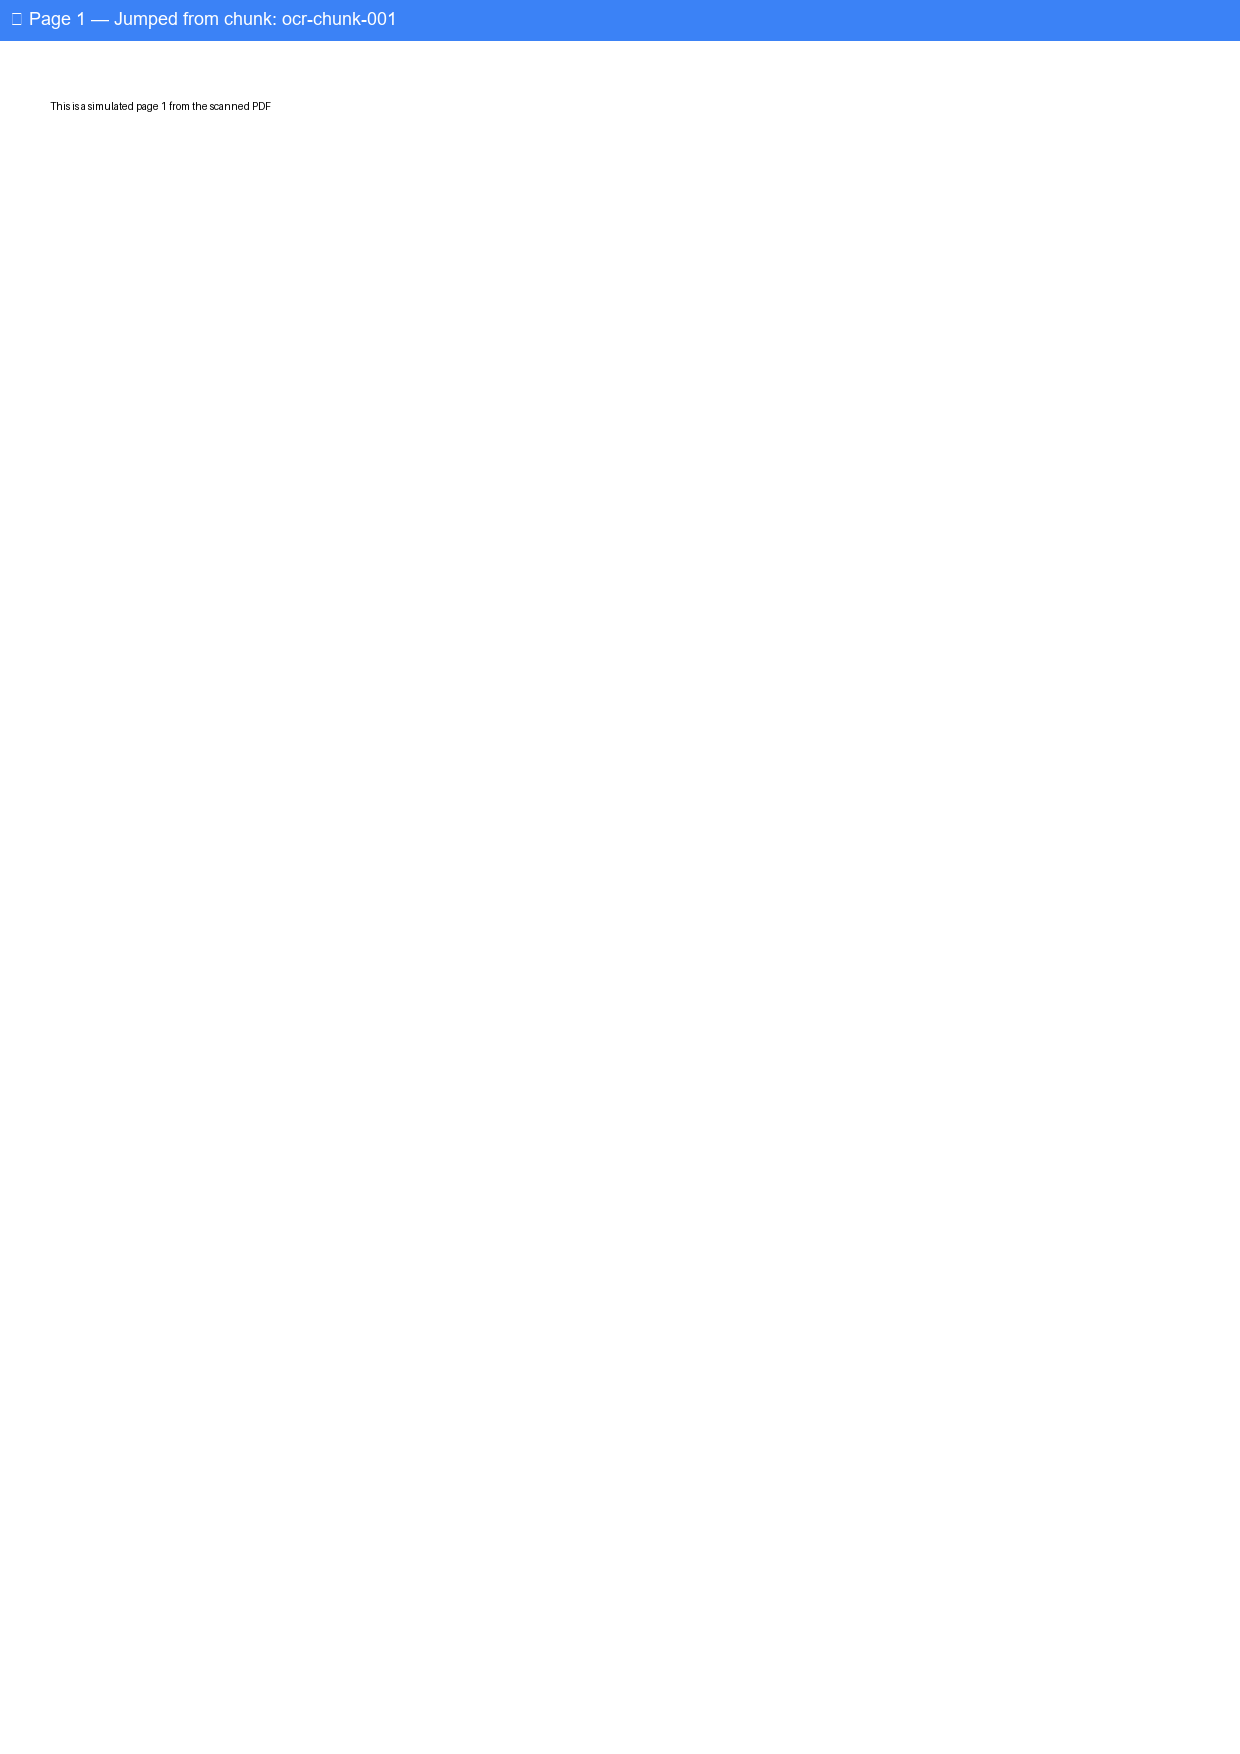


Demo 2: User clicks chunk 'ocr-chunk-003' (Executive Summary)
  Chunk 'ocr-chunk-003' requires PDF page: 3


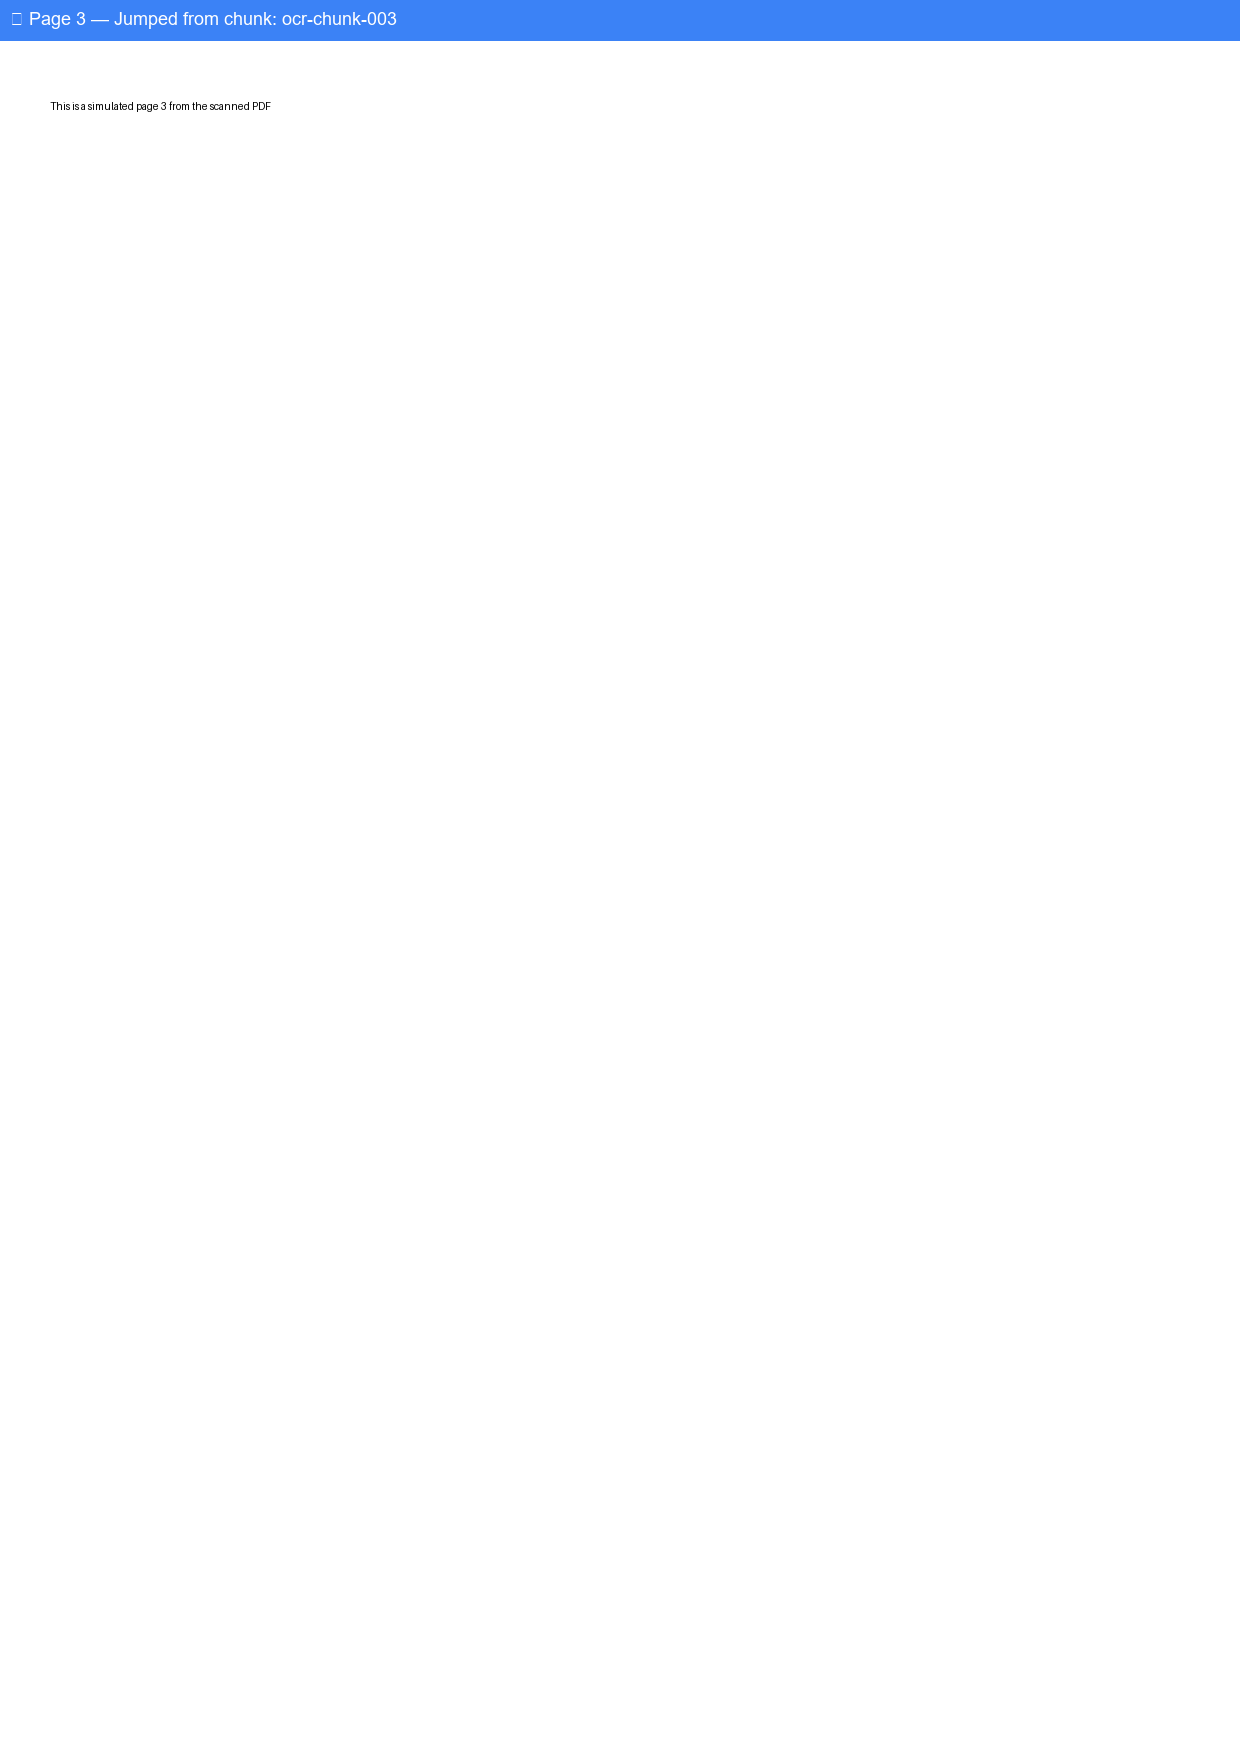


✅ 演示完成：不同 chunk 正确跳转到不同的 PDF 页面


In [9]:
from IPython.display import display, Image as IPyImage
from PIL import Image as PILImage

# 检查 poppler 是否可用（从 Step 2 继承的全局变量）
try:
    POPPLER_AVAILABLE
except NameError:
    POPPLER_AVAILABLE = False

def show_pdf_page_for_chunk(chunk, pdf_path):
    """核心函数：给定一个 chunk，渲染 PDF 对应页码的图片"""

    # ⭐ 第 1 步：从 chunk 读取页码（前端唯一需要的逻辑）
    page_number = chunk.positions[0].page_number
    print(f"  Chunk '{chunk.chunk_id}' requires PDF page: {page_number}")

    # 第 2 步：将 PDF 该页转为图片（模拟前端渲染）
    try:
        if POPPLER_AVAILABLE:
            images = convert_from_path(pdf_path, dpi=150, first_page=page_number, last_page=page_number)
            page_img = images[0]
        else:
            raise Exception("poppler not available")
    except Exception:
        # 无 poppler 时用预生成的页面图片
        page_img = Image.open(f"mock_output/page_{page_number}.png")

    # 第 3 步：在图片上标注 chunk 信息
    from PIL import ImageDraw, ImageFont
    draw = ImageDraw.Draw(page_img)
    # 在顶部画一个蓝色条幅
    draw.rectangle([0, 0, page_img.width, 40], fill=(59, 130, 246))
    # 使用默认字体
    try:
        font = ImageFont.truetype("arial.ttf", 18)
    except:
        font = ImageFont.load_default()

    draw.text((10, 8), f"📄 Page {page_number} — Jumped from chunk: {chunk.chunk_id}", fill=(255, 255, 255), font=font)

    return page_img, page_number

# ===== 演示 1：用户点击 "ocr-chunk-001"（第 1 页，封面）=====
print("=" * 60)
print("Demo 1: User clicks chunk 'ocr-chunk-001' (Cover page)")
print("=" * 60)
img1, pg1 = show_pdf_page_for_chunk(chunks[0], pdf_path)
display(img1)
print()

# ===== 演示 2：用户点击 "ocr-chunk-003"（第 3 页，正文）=====
print("=" * 60)
print("Demo 2: User clicks chunk 'ocr-chunk-003' (Executive Summary)")
print("=" * 60)
img3, pg3 = show_pdf_page_for_chunk(chunks[2], pdf_path)
display(img3)
print()

print("✅ 演示完成：不同 chunk 正确跳转到不同的 PDF 页面")


## Step 7: 端到端模拟 — RAG 查询 + 跳转

模拟完整流程：用户提问 → RAG 检索 → 命中 chunk → 前端跳转到对应 PDF 页。


In [10]:
class MockRAGPipeline:
    def __init__(self, chunks):
        self.chunks = chunks

    def query(self, question):
        """模拟 RAG 检索，返回命中的 chunks"""
        q = question.lower()
        scored = []
        for c in self.chunks:
            # 简单关键词匹配模拟检索
            score = sum(1 for w in q.split() if w in c.content.lower())
            scored.append((score, c))
        scored.sort(key=lambda x: -x[0])
        top_chunks = [c for score, c in scored if score > 0]

        if not top_chunks:
            return {"question": question, "chunks": [], "message": "No relevant chunks found"}

        return {
            "question": question,
            "chunks": [c.to_dict() for c in top_chunks],
            "total": len(top_chunks),
        }

pipe = MockRAGPipeline(chunks)

# 模拟用户提问
queries = [
    "What is RAG and what did RAGFlow achieve?",
    "What are the financial highlights?",
    "Tell me about the table of contents",
]

for q in queries:
    print("=" * 60)
    print(f"Q: {q}")
    print("=" * 60)
    result = pipe.query(q)

    if not result.get("chunks"):
        print("  No results found.")
        print()
        continue

    for i, c in enumerate(result["chunks"]):
        page = c["positions"][0]["page_number"]
        print(f"\n  Hit {i+1}: {c['chunk_id']}")
        print(f"    Content: {c['content'][:60]}...")
        print(f"    PDF page: {page}")
        print(f"    ──→ React 代码: <Page pageNumber={{{page}}} />")
    print()


Q: What is RAG and what did RAGFlow achieve?

  Hit 1: ocr-chunk-003
    Content: 1. Executive Summary
RAG is a powerful paradigm that combine...
    PDF page: 3
    ──→ React 代码: <Page pageNumber={3} />

  Hit 2: ocr-chunk-001
    Content: Annual Report 2025
RAGFlow Corporation
Published: January 20...
    PDF page: 1
    ──→ React 代码: <Page pageNumber={1} />

  Hit 3: ocr-chunk-002
    Content: Table of Contents
1. Executive Summary ................... 3...
    PDF page: 2
    ──→ React 代码: <Page pageNumber={2} />

Q: What are the financial highlights?

  Hit 1: ocr-chunk-002
    Content: Table of Contents
1. Executive Summary ................... 3...
    PDF page: 2
    ──→ React 代码: <Page pageNumber={2} />

  Hit 2: ocr-chunk-003
    Content: 1. Executive Summary
RAG is a powerful paradigm that combine...
    PDF page: 3
    ──→ React 代码: <Page pageNumber={3} />

Q: Tell me about the table of contents

  Hit 1: ocr-chunk-002
    Content: Table of Contents
1. Executive Summary .....

## Step 8: HTML 模拟 — 前端 PDF 页面导航器

生成一个可交互的 HTML，模拟前端行为：左侧显示 chunk，点击后右侧跳转到 PDF 对应页。


In [11]:
import base64

# 将所有 PDF 页面转为 base64 图片，嵌入 HTML
page_base64 = []
for i in range(1, 4):
    img = Image.open(f"mock_output/page_{i}.png")
    buf = BytesIO()
    img.save(buf, format="PNG")
    b64 = base64.b64encode(buf.getvalue()).decode()
    page_base64.append(b64)

# 生成 HTML
chunks_data = []
for c in chunks:
    chunks_data.append({
        "id": c.chunk_id,
        "content": c.content,
        "page": c.positions[0].page_number,
    })

import json
chunks_json = json.dumps(chunks_data)

html_content = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>OCR PDF Page Navigator</title>
<style>
  * {{ margin: 0; padding: 0; box-sizing: border-box; }}
  body {{ font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', sans-serif;
          background: #f0f2f5; height: 100vh; }}
  .container {{ display: flex; height: 100vh; }}
  .sidebar {{ width: 380px; background: #fff; border-right: 1px solid #e5e7eb;
              display: flex; flex-direction: column; }}
  .sidebar-header {{ padding: 16px 20px; border-bottom: 1px solid #e5e7eb;
                     background: #1e40af; color: white; }}
  .sidebar-header h2 {{ font-size: 16px; font-weight: 600; }}
  .sidebar-header p {{ font-size: 12px; opacity: 0.8; margin-top: 4px; }}
  .chunk-list {{ flex: 1; overflow-y: auto; padding: 12px; }}
  .chunk-card {{ padding: 14px; border-radius: 8px; border: 2px solid #e5e7eb;
                margin-bottom: 10px; cursor: pointer; transition: all 0.2s; }}
  .chunk-card:hover {{ border-color: #93c5fd; background: #eff6ff; }}
  .chunk-card.active {{ border-color: #2563eb; background: #dbeafe; }}
  .chunk-id {{ font-size: 12px; font-weight: 600; color: #2563eb; margin-bottom: 6px; }}
  .chunk-content {{ font-size: 13px; color: #374151; line-height: 1.5;
                    display: -webkit-box; -webkit-line-clamp: 3; -webkit-box-orient: vertical;
                    overflow: hidden; }}
  .chunk-page {{ display: inline-block; margin-top: 8px; padding: 2px 10px;
                 background: #dbeafe; color: #1e40af; border-radius: 12px;
                 font-size: 12px; font-weight: 500; }}
  .main-area {{ flex: 1; display: flex; flex-direction: column; align-items: center;
                justify-content: center; padding: 24px; position: relative; }}
  .page-display {{ background: white; border-radius: 12px; box-shadow: 0 4px 20px rgba(0,0,0,0.12);
                   overflow: hidden; max-width: 95%; }}
  .page-header {{ padding: 12px 20px; background: #1e40af; color: white;
                  display: flex; align-items: center; justify-content: space-between; }}
  .page-header h3 {{ font-size: 15px; font-weight: 500; }}
  .page-nav {{ display: flex; gap: 8px; }}
  .page-nav button {{ padding: 4px 16px; border: 1px solid rgba(255,255,255,0.4);
                      background: rgba(255,255,255,0.15); color: white; border-radius: 6px;
                      cursor: pointer; font-size: 13px; }}
  .page-nav button:hover {{ background: rgba(255,255,255,0.25); }}
  .page-nav button:disabled {{ opacity: 0.3; cursor: not-allowed; }}
  .page-image {{ padding: 16px; display: flex; justify-content: center; }}
  .page-image img {{ max-width: 100%; height: auto; border: 1px solid #e5e7eb; }}
  .empty-state {{ color: #9ca3af; text-align: center; }}
  .empty-state h3 {{ font-size: 20px; margin-bottom: 8px; }}
  .empty-state p {{ font-size: 14px; }}
  .badge {{ background: #fef3c7; color: #92400e; padding: 2px 8px; border-radius: 4px;
            font-size: 11px; font-weight: 500; }}
</style>
</head>
<body>
<div class="container">
  <!-- Sidebar -->
  <div class="sidebar">
    <div class="sidebar-header">
      <h2>📄 RAG OCR Results</h2>
      <p>Click a chunk to jump to its PDF page</p>
    </div>
    <div class="chunk-list" id="chunkList">
      <!-- chunks rendered by JS -->
    </div>
  </div>
  <!-- Main area -->
  <div class="main-area" id="mainArea">
    <div class="empty-state" id="emptyState">
      <h3>👈 点击左侧 chunk</h3>
      <p>选择任意 chunk 查看对应的 PDF 页面</p>
    </div>
    <div class="page-display" id="pageDisplay" style="display:none;">
      <div class="page-header">
        <h3 id="pageTitle">PDF Preview</h3>
        <div class="page-nav">
          <button id="prevBtn" onclick="navigate(-1)">◀</button>
          <button id="nextBtn" onclick="navigate(1)">▶</button>
        </div>
      </div>
      <div class="page-image">
        <img id="pageImage" src="" alt="PDF Page">
      </div>
    </div>
  </div>
</div>

<script>
const pages = {page_base64};
const chunks = {chunks_json};
let currentPage = 1;

function renderChunks() {{
  const list = document.getElementById('chunkList');
  list.innerHTML = chunks.map(c => `
    <div class="chunk-card" onclick="jumpToPage(${{c.page}}, '${{c.id}}')">
      <div class="chunk-id">${{c.id}}</div>
      <div class="chunk-content">${{c.content.substring(0, 100)}}</div>
      <div class="chunk-page">📄 Page ${{c.page}}</div>
    </div>
  `).join('');
}}

function jumpToPage(page, chunkId) {{
  currentPage = page;
  updateDisplay(chunkId);
}}

function navigate(delta) {{
  const newPage = currentPage + delta;
  if (newPage >= 1 && newPage <= pages.length) {{
    currentPage = newPage;
    updateDisplay(null);
  }}
}}

function updateDisplay(chunkId) {{
  document.getElementById('emptyState').style.display = 'none';
  const display = document.getElementById('pageDisplay');
  display.style.display = 'block';

  document.getElementById('pageTitle').textContent =
    `📄 Page ${{currentPage}}` + (chunkId ? ` — jumped from ${{chunkId}}` : '');

  document.getElementById('pageImage').src = `data:image/png;base64,${{pages[currentPage - 1]}}`;

  document.getElementById('prevBtn').disabled = currentPage <= 1;
  document.getElementById('nextBtn').disabled = currentPage >= pages.length;

  // 高亮对应的 chunk card
  document.querySelectorAll('.chunk-card').forEach(el => el.classList.remove('active'));
  if (chunkId) {{
    document.querySelectorAll('.chunk-card').forEach((el, i) => {{
      if (chunks[i].id === chunkId) el.classList.add('active');
    }});
  }}
}}

renderChunks();
</script>
</body>
</html>"""

html_path = "mock_output/ocr_page_navigator.html"
with open(html_path, "w", encoding="utf-8") as f:
    f.write(html_content)
print(f"HTML generated: {html_path}")
print(f"Size: {os.path.getsize(html_path)} bytes")


HTML generated: mock_output/ocr_page_navigator.html
Size: 60876 bytes


In [12]:
from IPython.display import IFrame

display(IFrame(html_path, width=950, height=700))
print("可在浏览器中打开 mock_output/ocr_page_navigator.html 查看完整交互效果")


可在浏览器中打开 mock_output/ocr_page_navigator.html 查看完整交互效果


## Step 9: 前端 React 代码参考

在实际 React 项目中，使用 `react-pdf` 实现同样的跳页逻辑。

### 安装

```bash
npm install react-pdf
```

### 核心代码

```tsx
import { useState, useEffect } from 'react';
import { Document, Page, pdfjs } from 'react-pdf';
import 'react-pdf/dist/esm/Page/AnnotationLayer.css';
import 'react-pdf/dist/esm/Page/TextLayer.css';

pdfjs.GlobalWorkerOptions.workerSrc = '/pdfjs-dist/pdf.worker.min.js';

// ⭐ 从 chunk 提取页码 — 就这么简单！
const getPageNumber = (chunk: any): number => {
  return chunk?.positions?.[0]?.page_number ?? 1;
};

function PdfViewer({ url, chunk }: { url: string; chunk: any }) {
  const [numPages, setNumPages] = useState(0);
  const [currentPage, setCurrentPage] = useState(getPageNumber(chunk));

  // chunk 切换时跳转到新页码
  useEffect(() => {
    setCurrentPage(getPageNumber(chunk));
  }, [chunk]);

  return (
    <Document
      file={url}
      options={{
        httpHeaders: { Authorization: `Bearer ${token}` },
        withCredentials: true,
      }}
      onLoadSuccess={({ numPages }) => setNumPages(numPages)}
    >
      <Page pageNumber={currentPage} width={800} />
      <p>第 {currentPage} 页 / 共 {numPages} 页</p>
    </Document>
  );
}
```

### 关键行

```tsx
// 整个方案的核心——只有这一行：
const page = chunk.positions[0].page_number;

// 传给 react-pdf：
<Page pageNumber={page} />
```


## 总结

### 核心结论

```
PDF 扫描件 ──→ OCR 解析 ──→ chunk（含 page_number）──→ 前端直接读取
                                                              │
                                                              ▼
                                                     <Page pageNumber={page_number} />
```

**chunk 的 `page_number` 不是前端计算的，而是 OCR 解析阶段就存好的数据。**

### 数据来源追溯

| 步骤 | 产出 | 页码来源 |
|------|------|---------|
| PDF 每页转图片 | N 张图片 | 第 1 张图片 = 第 1 页 |
| OCR 识别每张图片 | 文本 + 坐标 | 图片的序号 = 页码 |
| 文本分块 | chunk | chunk.positions[0].page_number = 图片序号 |
| 前端读取 | pageNumber | ✅ 直接使用 |

### 前端代码（完整实现）

```tsx
// 1. 从 chunk 取页码
const pageNumber = chunk?.positions?.[0]?.page_number ?? 1;

// 2. 传给 react-pdf
<Page pageNumber={pageNumber} />
```

**没有坐标转换、没有高亮叠加、没有复杂的状态管理。就这 1 行代码。**
